# 01 — FI-2010 Data Exploration

This notebook explores the FI-2010 limit order book dataset used in the DeepLOB paper.

**What you'll learn:**
- What limit order book data looks like
- How the 40 features are organized (10 levels × 4 features)
- Label distributions across prediction horizons
- Basic statistics and visualizations

 **Study this on Desktop:** What is a Limit Order Book (LOB)? It's the list of all pending buy/sell orders at different price levels. Level 1 = best bid/ask (tightest spread), Level 10 = deepest.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch

# Add project root to path so we can import src/
PROJECT_ROOT = Path(".").resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.dataset import FI2010Dataset, HORIZON_TO_IDX

sns.set_theme(style="whitegrid", font_scale=1.1)
%matplotlib inline

## 1. Load Preprocessed Data

In [2]:
processed_dir = PROJECT_ROOT / "data" / "processed"

train_x = torch.load(processed_dir / "train_x.pt", weights_only=True)
train_y = torch.load(processed_dir / "train_y.pt", weights_only=True)
test_x = torch.load(processed_dir / "test_x.pt", weights_only=True)
test_y = torch.load(processed_dir / "test_y.pt", weights_only=True)

print(f"Train: X={train_x.shape}, Y={train_y.shape}")
print(f"Test:  X={test_x.shape}, Y={test_y.shape}")
print(f"\nEach sample: {train_x.shape[1]} timesteps × {train_x.shape[2]} features")

Train: X=torch.Size([203720, 100, 40]), Y=torch.Size([203720, 5])
Test:  X=torch.Size([139488, 100, 40]), Y=torch.Size([139488, 5])

Each sample: 100 timesteps × 40 features


## 2. Understanding the 40 Features

The 40 columns represent 10 LOB levels, each with 4 features:

| Column Index | Feature | Description |
|---|---|---|
| 0 | Ask Price 1 | Best (lowest) ask price |
| 1 | Ask Volume 1 | Volume at best ask |
| 2 | Bid Price 1 | Best (highest) bid price |
| 3 | Bid Volume 1 | Volume at best bid |
| 4 | Ask Price 2 | 2nd best ask price |
| ... | ... | ... |
| 36-39 | Level 10 | Deepest LOB level |

 **Study this on Desktop:** Bid-ask spread — the difference between best ask and best bid is the "spread". Tight spreads = liquid market. The LOB depth (volumes at each level) tells you about supply/demand.

In [3]:
# Look at a single LOB snapshot (one timestep from the first sample)
snapshot = train_x[0, 0, :].numpy()  # First sample, first timestep

feature_names = []
for level in range(1, 11):
    feature_names.extend([
        f"Ask_P{level}", f"Ask_V{level}", f"Bid_P{level}", f"Bid_V{level}"
    ])

print("Single LOB snapshot (first timestep of first sample):")
print("=" * 50)
for i, (name, val) in enumerate(zip(feature_names, snapshot)):
    print(f"  [{i:2d}] {name:10s}: {val:.6f}")
    if (i + 1) % 4 == 0:
        print()  # blank line between levels

Single LOB snapshot (first timestep of first sample):
  [ 0] Ask_P1    : 0.261500
  [ 1] Ask_V1    : 0.003530
  [ 2] Bid_P1    : 0.260600
  [ 3] Bid_V1    : 0.003260

  [ 4] Ask_P2    : 0.261800
  [ 5] Ask_V2    : 0.002000
  [ 6] Bid_P2    : 0.260400
  [ 7] Bid_V2    : 0.006820

  [ 8] Ask_P3    : 0.261900
  [ 9] Ask_V3    : 0.001640
  [10] Bid_P3    : 0.260200
  [11] Bid_V3    : 0.007860

  [12] Ask_P4    : 0.262000
  [13] Ask_V4    : 0.005320
  [14] Bid_P4    : 0.260000
  [15] Bid_V4    : 0.008930

  [16] Ask_P5    : 0.262100
  [17] Ask_V5    : 0.001510
  [18] Bid_P5    : 0.259900
  [19] Bid_V5    : 0.001590

  [20] Ask_P6    : 0.262300
  [21] Ask_V6    : 0.008370
  [22] Bid_P6    : 0.259500
  [23] Bid_V6    : 0.001000

  [24] Ask_P7    : 0.262500
  [25] Ask_V7    : 0.001500
  [26] Bid_P7    : 0.259300
  [27] Bid_V7    : 0.001430

  [28] Ask_P8    : 0.262600
  [29] Ask_V8    : 0.007870
  [30] Bid_P8    : 0.259100
  [31] Bid_V8    : 0.001340

  [32] Ask_P9    : 0.262900
  [33] Ask_V9 

## 3. Visualize a LOB Window (T=100 timesteps)

This is what the model "sees" as input — 100 consecutive snapshots of the order book.

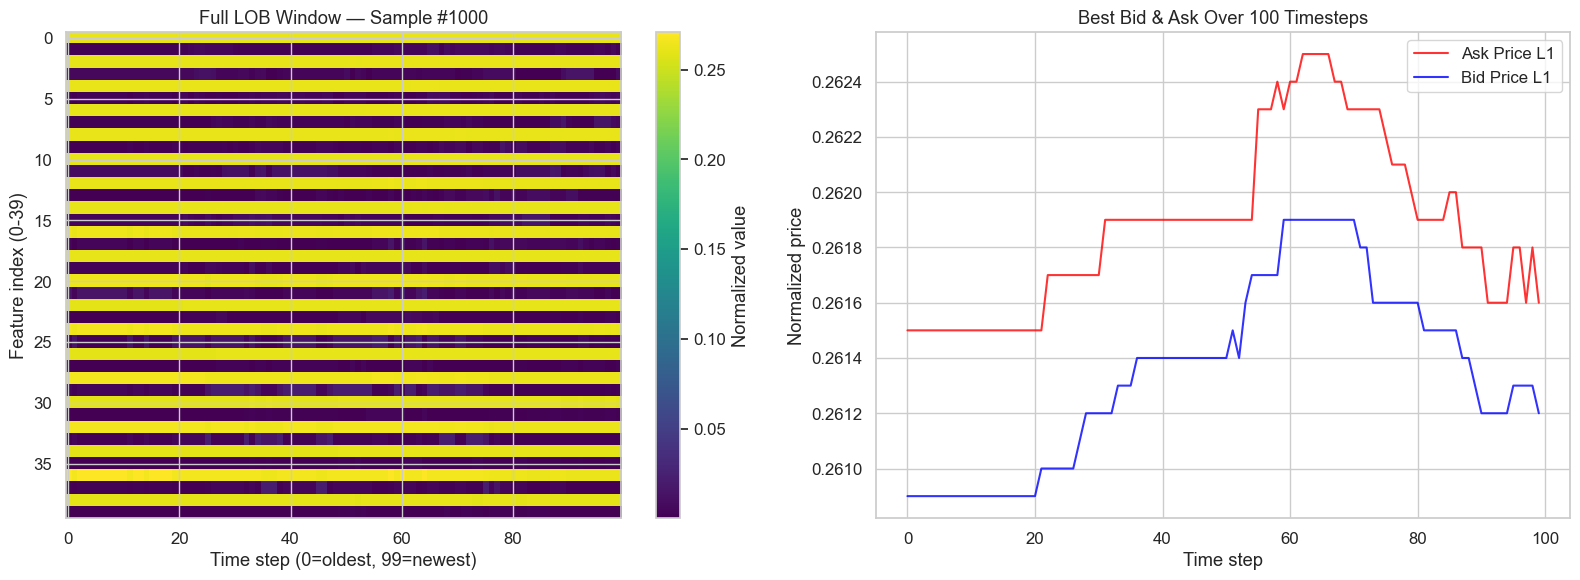

In [4]:
# Visualize the full (100, 40) input as a heatmap
sample_idx = 1000  # Pick a sample from the middle of training
sample = train_x[sample_idx].numpy()  # shape: (100, 40)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full heatmap
im = axes[0].imshow(sample.T, aspect="auto", cmap="viridis")
axes[0].set_xlabel("Time step (0=oldest, 99=newest)")
axes[0].set_ylabel("Feature index (0-39)")
axes[0].set_title(f"Full LOB Window — Sample #{sample_idx}")
plt.colorbar(im, ax=axes[0], label="Normalized value")

# Just the best bid/ask prices over time
axes[1].plot(sample[:, 0], label="Ask Price L1", color="red", alpha=0.8)
axes[1].plot(sample[:, 2], label="Bid Price L1", color="blue", alpha=0.8)
axes[1].set_xlabel("Time step")
axes[1].set_ylabel("Normalized price")
axes[1].set_title("Best Bid & Ask Over 100 Timesteps")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Label Distribution Across Horizons

The model predicts price direction: **down (0)**, **stationary (1)**, or **up (2)**.

Different prediction horizons (k) have very different class balances:
- Short horizon (k=10): mostly stationary — hard to predict small moves
- Long horizon (k=100): more balanced — larger moves are easier to classify

 **Study this on Desktop:** Class imbalance — when one class dominates, accuracy alone is misleading (a model predicting "stationary" for everything gets ~70% accuracy at k=10!). That's why we report **weighted F1 score**.

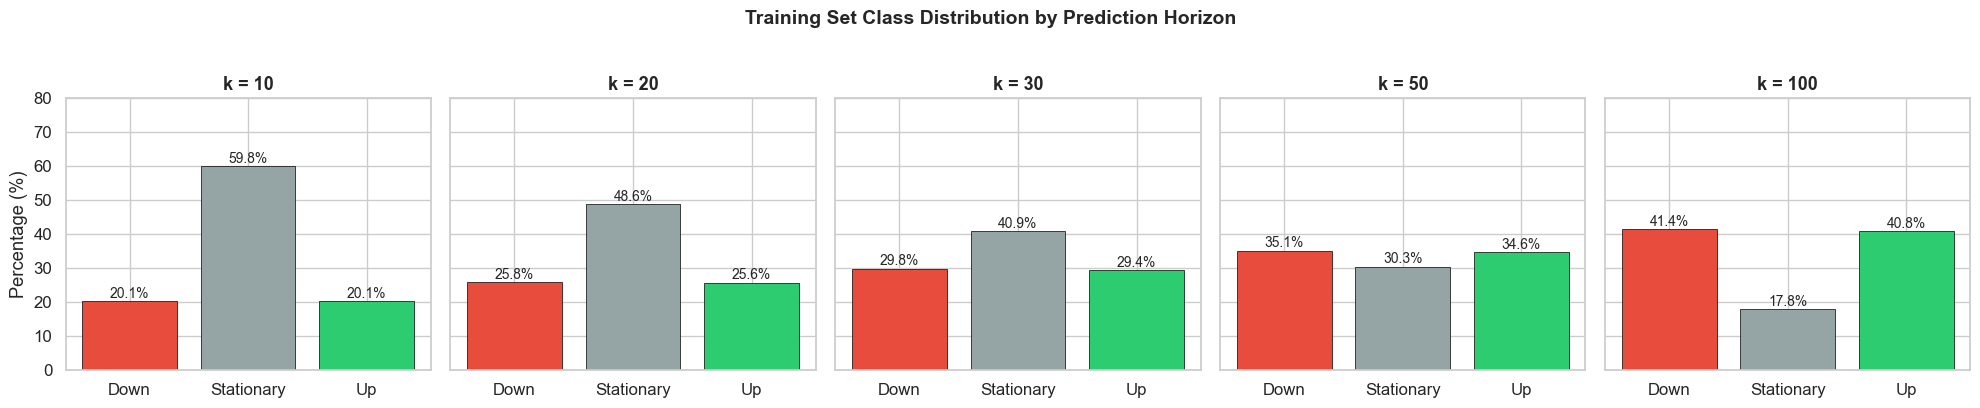

In [5]:
horizons = [10, 20, 30, 50, 100]
class_names = ["Down", "Stationary", "Up"]
colors = ["#e74c3c", "#95a5a6", "#2ecc71"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

for ax, horizon in zip(axes, horizons):
    h_idx = HORIZON_TO_IDX[horizon]
    labels = train_y[:, h_idx].numpy()
    counts = np.bincount(labels, minlength=3)
    pcts = counts / len(labels) * 100

    bars = ax.bar(class_names, pcts, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_title(f"k = {horizon}", fontsize=13, fontweight="bold")
    ax.set_ylim(0, 80)

    # Add percentage labels on bars
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f"{pct:.1f}%", ha="center", fontsize=10)

axes[0].set_ylabel("Percentage (%)")
fig.suptitle("Training Set Class Distribution by Prediction Horizon",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 5. Train vs Test Distribution Comparison

We need to check if the class distribution shifts between train and test.
A large shift would make the classification harder (distribution shift / covariate shift).

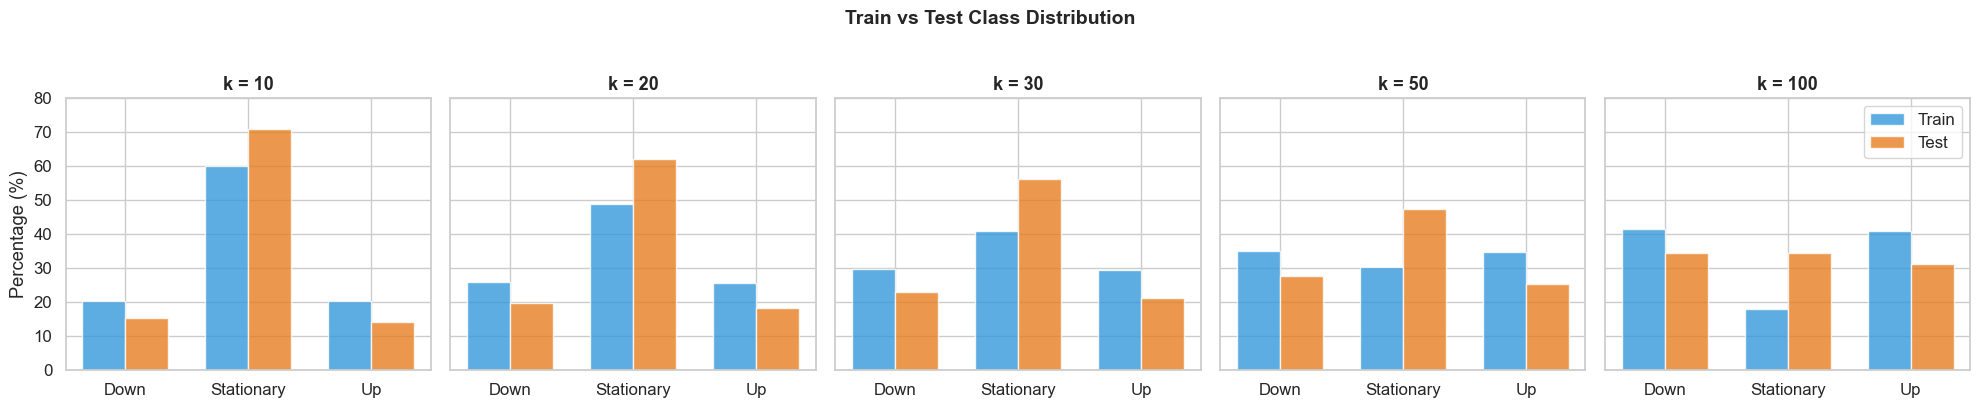

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

for ax, horizon in zip(axes, horizons):
    h_idx = HORIZON_TO_IDX[horizon]

    train_labels = train_y[:, h_idx].numpy()
    test_labels = test_y[:, h_idx].numpy()

    train_pcts = np.bincount(train_labels, minlength=3) / len(train_labels) * 100
    test_pcts = np.bincount(test_labels, minlength=3) / len(test_labels) * 100

    x = np.arange(3)
    width = 0.35
    ax.bar(x - width/2, train_pcts, width, label="Train", color="#3498db", alpha=0.8)
    ax.bar(x + width/2, test_pcts, width, label="Test", color="#e67e22", alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(class_names)
    ax.set_title(f"k = {horizon}", fontsize=13, fontweight="bold")
    ax.set_ylim(0, 80)

axes[0].set_ylabel("Percentage (%)")
axes[-1].legend()
fig.suptitle("Train vs Test Class Distribution",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 6. Feature Statistics

The data is pre-normalized using decimal precision scaling.
Let's check the distribution of feature values.

In [7]:
# Compute per-feature statistics across all training samples
# Reshape: (N, 100, 40) → (N*100, 40) to get stats per feature
flat = train_x.reshape(-1, 40).numpy()

print("Per-feature statistics (across all training timesteps):")
print(f"{'Feature':>12s}  {'Mean':>8s}  {'Std':>8s}  {'Min':>8s}  {'Max':>8s}")
print("-" * 52)
for i in range(0, 40, 4):  # Show one level at a time
    level = i // 4 + 1
    for j, suffix in enumerate(["Ask_P", "Ask_V", "Bid_P", "Bid_V"]):
        col = i + j
        print(f"{suffix}{level:d}:  "
              f"{flat[:, col].mean():>8.4f}  "
              f"{flat[:, col].std():>8.4f}  "
              f"{flat[:, col].min():>8.4f}  "
              f"{flat[:, col].max():>8.4f}")
    if level <= 3:  # Only show first 3 levels to keep it readable
        continue
    else:
        print("  ... (showing first 3 of 10 levels)")
        break

Per-feature statistics (across all training timesteps):
     Feature      Mean       Std       Min       Max
----------------------------------------------------


Ask_P1:    0.1984    0.0898    0.1203    0.3668


Ask_V1:    0.0127    0.0146    0.0000    0.2450


Bid_P1:    0.1981    0.0896    0.1202    0.3659


Bid_V1:    0.0139    0.0175    0.0000    0.6000


...

Bid_V3:    0.0276    0.0286    0.0000    0.6000


Ask_P4:    0.1988    0.0899    0.1206    0.3673


Ask_V4:    0.0287    0.0261    0.0000    0.5348


Bid_P4:    0.1977    0.0896    0.1199    0.3656


Bid_V4:    0.0308    0.0292    0.0000    0.3574
  ... (showing first 3 of 10 levels)


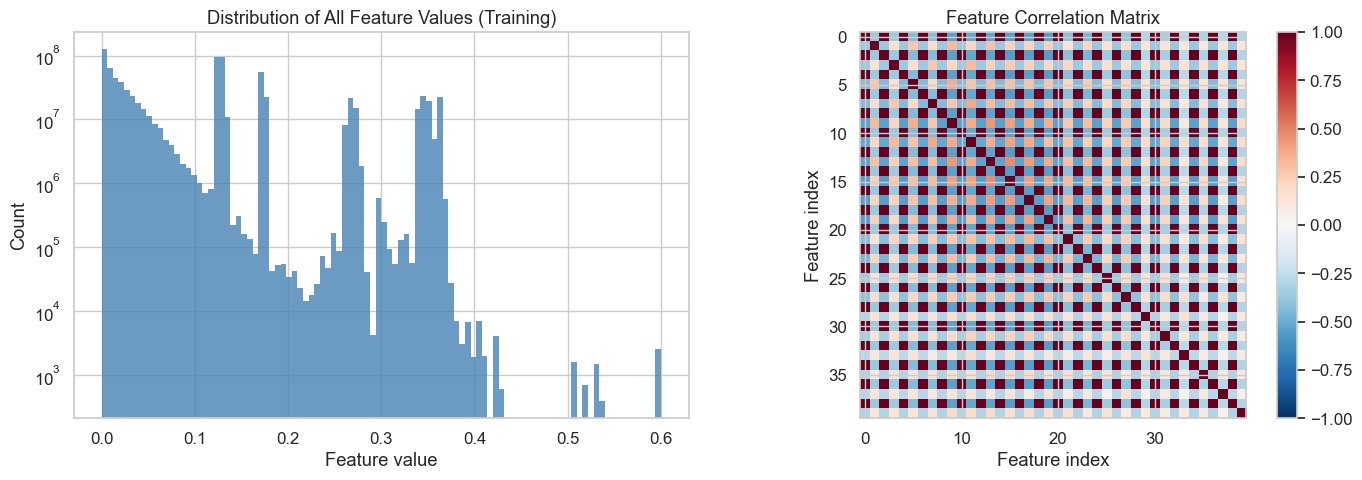

In [8]:
# Distribution of all feature values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of all values
axes[0].hist(flat.ravel(), bins=100, color="steelblue", edgecolor="none", alpha=0.8)
axes[0].set_xlabel("Feature value")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of All Feature Values (Training)")
axes[0].set_yscale("log")

# Correlation between features (using a random subset to speed up)
subset_idx = np.random.choice(len(flat), size=min(50000, len(flat)), replace=False)
corr = np.corrcoef(flat[subset_idx].T)
im = axes[1].imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_xlabel("Feature index")
axes[1].set_ylabel("Feature index")
axes[1].set_title("Feature Correlation Matrix")
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

## 7. LOB Depth Profile Visualization

Visualize what the order book looks like at a single point in time.
This shows the "depth" of the market — how much volume is available at each price level.

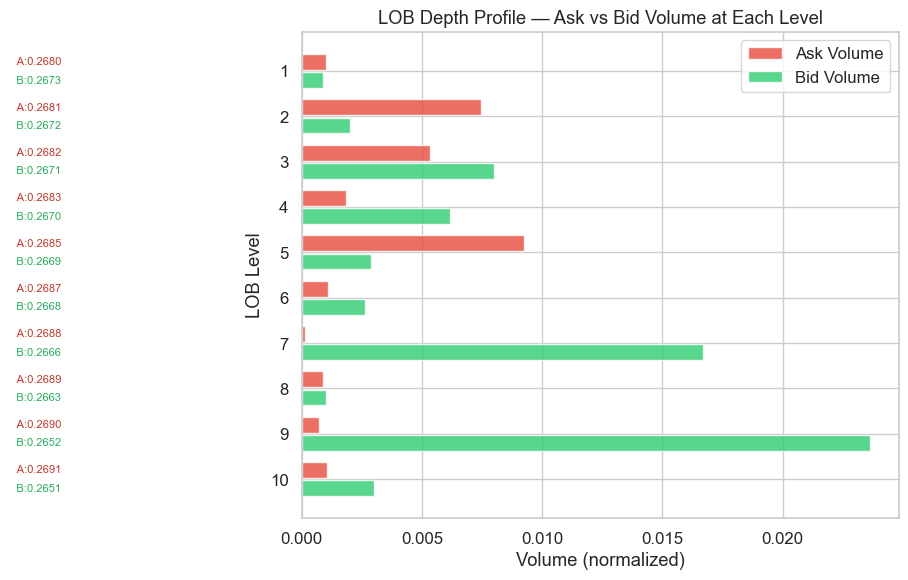

In [9]:
# Take a single timestep and plot the LOB depth profile
snapshot = train_x[5000, 50, :].numpy()  # sample 5000, middle timestep

ask_prices = snapshot[0::4][:10]   # Every 4th starting at 0
ask_volumes = snapshot[1::4][:10]  # Every 4th starting at 1
bid_prices = snapshot[2::4][:10]   # Every 4th starting at 2
bid_volumes = snapshot[3::4][:10]  # Every 4th starting at 3

fig, ax = plt.subplots(figsize=(10, 6))

levels = np.arange(1, 11)
ax.barh(levels - 0.2, ask_volumes, height=0.35, color="#e74c3c", alpha=0.8, label="Ask Volume")
ax.barh(levels + 0.2, bid_volumes, height=0.35, color="#2ecc71", alpha=0.8, label="Bid Volume")

ax.set_xlabel("Volume (normalized)")
ax.set_ylabel("LOB Level")
ax.set_yticks(levels)
ax.set_title("LOB Depth Profile — Ask vs Bid Volume at Each Level")
ax.legend()
ax.invert_yaxis()  # Level 1 at top

# Add price annotations
for i, level in enumerate(levels):
    ax.text(-0.01, level - 0.2, f"  A:{ask_prices[i]:.4f}", ha="right", va="center",
            fontsize=8, color="#c0392b")
    ax.text(-0.01, level + 0.2, f"  B:{bid_prices[i]:.4f}", ha="right", va="center",
            fontsize=8, color="#27ae60")

plt.tight_layout()
plt.show()

## 8. Verify DataLoader Output

Quick sanity check that our `FI2010Dataset` produces the right shapes for DeepLOB.

In [10]:
# Test the dataset class
dataset = FI2010Dataset(train_x, train_y, horizon=10)
loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)

batch_x, batch_y = next(iter(loader))

print(f"Batch X shape: {batch_x.shape}  (expected: [64, 1, 100, 40])")
print(f"Batch Y shape: {batch_y.shape}  (expected: [64])")
print(f"X dtype: {batch_x.dtype}  (expected: float32)")
print(f"Y dtype: {batch_y.dtype}  (expected: int64)")
print(f"Y values: {batch_y[:10]}  (should be 0, 1, or 2)")
print(f"\nTotal samples: {len(dataset)}")
print(f"Total batches: {len(loader)}")
print("\n DataLoader output matches DeepLOB input spec!")

Batch X shape: torch.Size([64, 1, 100, 40])  (expected: [64, 1, 100, 40])
Batch Y shape: torch.Size([64])  (expected: [64])
X dtype: torch.float32  (expected: float32)
Y dtype: torch.int64  (expected: int64)
Y values: tensor([0, 0, 1, 1, 2, 2, 2, 2, 2, 0])  (should be 0, 1, or 2)

Total samples: 203720
Total batches: 3184

✅ DataLoader output matches DeepLOB input spec!


## Summary

**Key takeaways:**
1. FI-2010 has ~204K training samples, ~51K validation samples, and ~139K test samples (after sliding window)
2. Each input is (1, 100, 40) — a "1-channel image" of 100 LOB snapshots
3. **Severe class imbalance at k=10** (~60% stationary) — must use weighted F1
4. Class distributions shift between train and test — this is realistic market behavior
5. Data is pre-normalized (Decimal Precision) with values in [0, 0.6]

**Next steps:**
- Phase 2: Implement the DeepLOB architecture (CNN → Inception → LSTM → FC)
- See `docs/deeplob_paper_reference.md` for exact architecture specifications